In [13]:
import mne
import matplotlib.pyplot as plt

watermelon = mne.io.read_raw_brainvision('current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr', preload=True)

chs = watermelon.info["ch_names"][0:24]

watermelon.pick(chs)

watermelon.crop(tmin=1855.415, tmax=2813.099)
watermelon.set_annotations(None)
watermelon.resample(512.)
watermelon = watermelon.copy().filter(l_freq=0.5, h_freq=None, verbose=False)
#watermelon.plot()

Extracting parameters from current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr...
Setting channel info structure...
Reading 0 ... 17386799  =      0.000 ...  3477.360 secs...


C:\Users\np3106\AppData\Local\Temp\ipykernel_19084\2619885410.py:4: RuntimeWarning: No coordinate information found for channels ['EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  watermelon = mne.io.read_raw_brainvision('current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr', preload=True)
C:\Users\np3106\AppData\Local\Temp\ipykernel_19084\2619885410.py:4: RuntimeWarning: Not setting positions of 4 misc channels found in montage:
['EMG1', 'EMG2', 'EMG3', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  watermelon = mne.io.read_raw_brainvision('current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr', preload=True)


Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


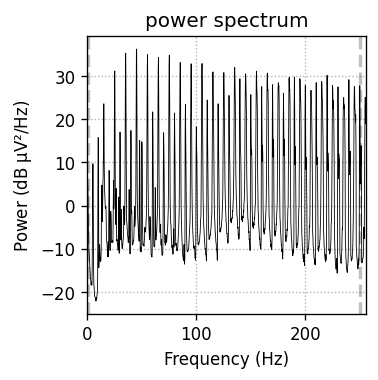

In [34]:
k = watermelon.compute_psd(method='welch')

spectrum = k

fig, ax = plt.subplots(figsize=(3,3), dpi=120)
# Same ideas as plot_ica_properties: dB scaling and optional log x-axis
spectrum.plot(
    picks=[0], axes=ax, average=True, dB=True,
    xscale='linear'
    #xscale='log',  # set False/'linear' if you don’t want log freq
)
ax.set_title('power spectrum')
plt.show();


Plotting power spectral density (dB=True).


c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


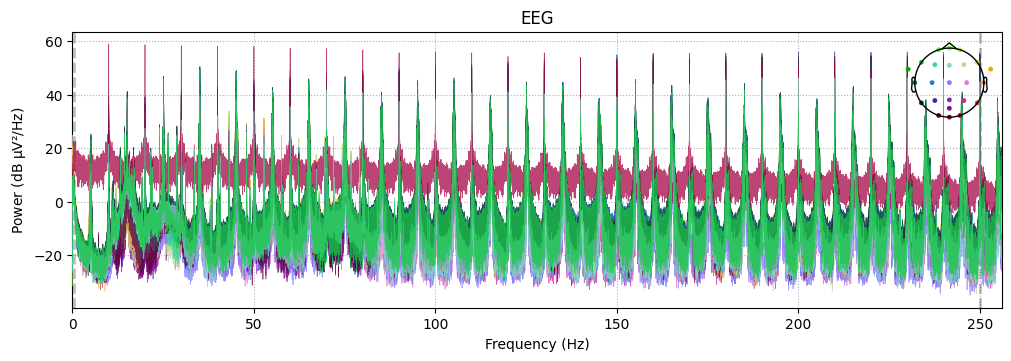

In [15]:
k.plot()

In [16]:
watermelon.plot()
plt.show();

Using qt as 2D backend.


Channels marked as bad:
none


In [2]:
# Remove slow drift
watermelon_hp = watermelon.copy().filter(l_freq=0.5, h_freq=None, verbose=False)

In [ ]:
import numpy as np

def epoch_data(eeg_segment, window_size_time):
  s_freq = eeg_segment.info["sfreq"]
  window_size = int(window_size_time * s_freq)

  # Sample indices from 0 up to len(eeg_segment)
  steady_samples = np.arange(0, len(eeg_segment) - window_size, window_size)
  events = np.vstack([ steady_samples + eeg_segment.first_samp,
                      np.zeros(len(steady_samples)),
                      np.ones(len(steady_samples))]).astype(int).T
  
  # Create an epochs object with our events
  epochs = mne.Epochs(eeg_segment, events, tmin=0, tmax=window_size_time-(1/s_freq),
                      baseline=(0, 0), reject=None, flat=None,
                      reject_by_annotation=False, verbose=False)
  return epochs.get_data()

window_size_time = 3 * 0.125 # 3 TR
noise_segments = []
noise_data = epoch_data(watermelon_hp, window_size_time)



Using data from preloaded Raw for 2553 events and 192 original time points ...


0 bad epochs dropped


In [9]:
noise_data.shape

(2553, 26, 192)

In [ ]:
from pathlib import Path
out_path = Path("data_segmented") / 'watermelon.npy'
np.save(out_path, noise_data)

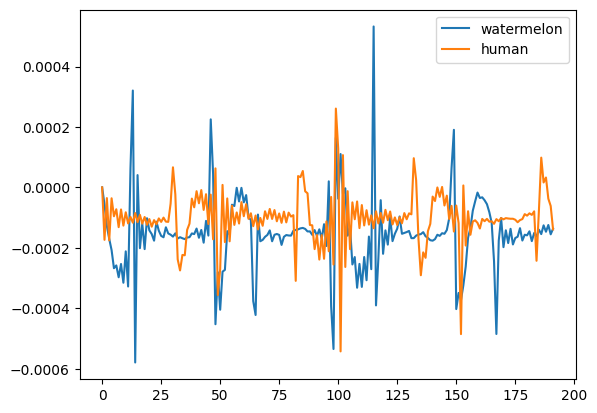

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
contaminated= np.load('data_segmented/16/dirty.npy');
noise_data = np.load('data_segmented/watermelon.npy');
plt.plot(noise_data[1,0,:], label = "watermelon")
plt.plot(contaminated[1,0,:], label="human")
plt.legend()

In [7]:
raw = mne.io.read_raw_brainvision('current_study_data_raw/H016/016_scan.vhdr', preload=True)

chs = [
   'Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2',
  'F7','F8','T7','T8','P7','P8','FPz','Fz','Cz','Pz',
   'POz','Oz','FT9','FT10',"TP9'","TP10'",
   ]
raw.pick(chs)
raw.crop(tmin=654.76, tmax=1612.33)
raw.set_annotations(None)
raw.resample(512.)

Extracting parameters from current_study_data_raw/H016/016_scan.vhdr...
Setting channel info structure...
Reading 0 ... 31733799  =      0.000 ...  6346.760 secs...


C:\Users\np3106\AppData\Local\Temp\ipykernel_22008\1199879534.py:1: RuntimeWarning: No coordinate information found for channels ['EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  raw = mne.io.read_raw_brainvision('current_study_data_raw/H016/016_scan.vhdr', preload=True)
C:\Users\np3106\AppData\Local\Temp\ipykernel_22008\1199879534.py:1: RuntimeWarning: Not setting positions of 4 misc channels found in montage:
['EMG1', 'EMG2', 'EMG3', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw = mne.io.read_raw_brainvision('current_study_data_raw/H016/016_scan.vhdr', preload=True)


<RawBrainVision | 016_scan.eeg, 26 x 490276 (957.6 s), ~97.3 MiB, data loaded>

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.000 (s)


c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


Plotting power spectral density (dB=True).


c:\Users\np3106\EEG_Cleaning_NaMRI\.venv\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


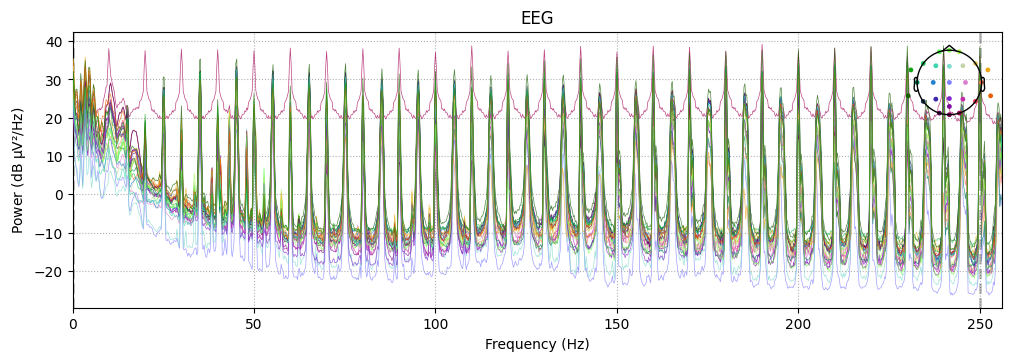

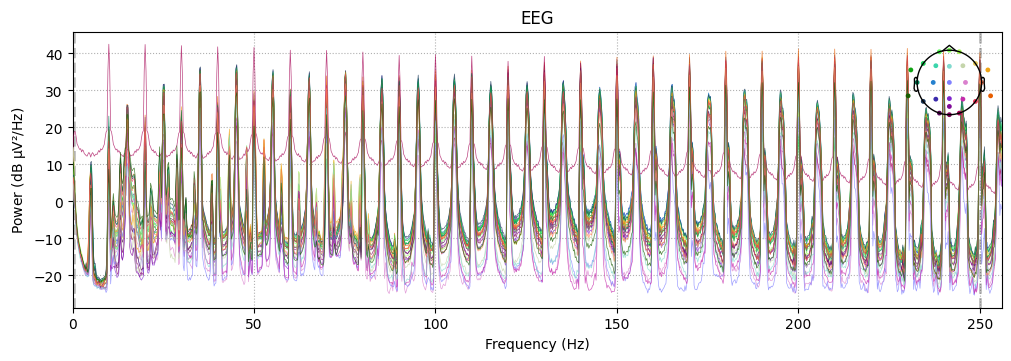

In [12]:
raw.plot_psd();
watermelon_hp.plot_psd();

In [18]:
import mne
import matplotlib.pyplot as plt

watermelon2 = mne.io.read_raw_brainvision('current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr', preload=True)

chs = [
   'Fp1','Fp2','F3','F4','C3','C4','P3','P4','O1','O2',
  'F7','F8','T7','T8','P7','P8','FPz','Fz','Cz','Pz',
   'POz','Oz','FT9','FT10',"TP9'","TP10'",
   ]
watermelon2.pick(chs)
watermelon2.set_annotations(None)
watermelon2.resample(512.)
watermelon2.plot();
plt.show();

Extracting parameters from current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr...
Setting channel info structure...
Reading 0 ... 17386799  =      0.000 ...  3477.360 secs...


C:\Users\np3106\AppData\Local\Temp\ipykernel_22008\1686507054.py:4: RuntimeWarning: No coordinate information found for channels ['EMG1', 'EMG2', 'EMG3', 'ECG']. Setting channel types to misc. To avoid this warning, set channel types explicitly.
  watermelon2 = mne.io.read_raw_brainvision('current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr', preload=True)
C:\Users\np3106\AppData\Local\Temp\ipykernel_22008\1686507054.py:4: RuntimeWarning: Not setting positions of 4 misc channels found in montage:
['EMG1', 'EMG2', 'EMG3', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  watermelon2 = mne.io.read_raw_brainvision('current_study_data_raw/watermelon2.0/watermelon2.0_scan.vhdr', preload=True)


Channels marked as bad:
none


In [5]:
import numpy as np
k=np.load('data_segmented/16/contaminated.npy')
k.shape

(11907, 26, 192)

Training on 4 subjects; validating on 1 subjects


C:\Users\np3106\AppData\Local\Temp\ipykernel_5476\3505372416.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


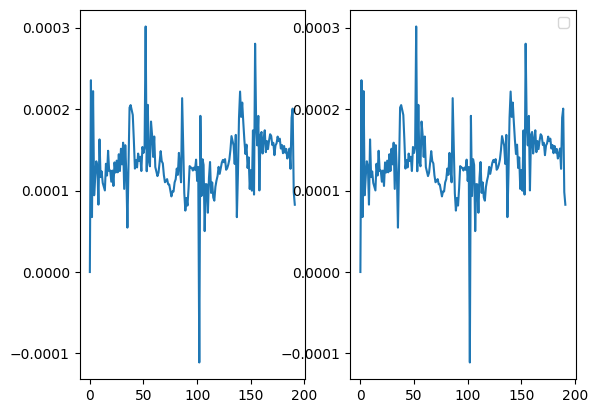

In [11]:
from pathlib import Path
from datasets import EEGDenoiseDataset
from torch.utils.data import DataLoader
import random
import matplotlib.pyplot as plt

root_dir="data_segmented/"
root_dir = Path(root_dir)
subj_dirs = sorted([p for p in root_dir.iterdir() if p.is_dir()])
watermelon_data = root_dir / "watermelon.npy"
random.seed(0)
random.shuffle(subj_dirs)

n_val = max(1, int(0.1 * len(subj_dirs)))
val_subj   = subj_dirs[:n_val]
train_subj = subj_dirs[n_val:]
print(f"Training on {len(train_subj)} subjects; validating on {len(val_subj)} subjects")

train_ds = EEGDenoiseDataset(train_subj)
train_dl = DataLoader(train_ds, batch_size=1, shuffle=True,
                      num_workers=0, pin_memory=True, drop_last=True)
x_raw, y, clean_i, noise_i, m, sd, ch, x_norm = next(iter(train_dl))

# reshape m and sd so they broadcast over (B, C, T)
m  = m.view(-1, 1, 1)
sd = sd.view(-1, 1, 1)

x_reconstructed = x_norm * sd + m        # should match x_raw

plt.subplot(1,2,1)
plt.plot(x_reconstructed[0, 0].numpy())
plt.subplot(1,2,2)
plt.plot(x_raw[0, 0].numpy())
plt.legend()
plt.show()